# Milestone 2 — Data Modeling
**Project:** Meeting Transcript Efficiency Analyzer  
**Course:** CAP5771 – Intro to Data Science


## What data_modeling.ipynb notebook does

We want to automatically classify every utterance in a meeting as a **decision**, an **action item**, or just a **general discussion**. To figure out which approach works best on our data, we will try five different classifiers and compare them.

After picking a model with highest accuracy, we also cluster the meetings themselves by efficiency profile, which feeds directly into the dashboard.

**Input files** (produced by `data_wrangling.ipynb`):
- `data/processed/analysis_ready.csv` — utterance level, with keyword labels + engineered features
- `data/processed/meeting_metrics.csv` — meeting level, with decision density, redundancy, etc.

**Five classifiers we compare:**

| # | Model | Why we chose it |
|---|---|---|
| 1 | Logistic Regression | Fast, linear baseline; coefficients are easy to interpret |
| 2 | Multinomial Naive Bayes | Classic NLP choice; very efficient on sparse TF-IDF |
| 3 | Linear SVM | Strong on high-dimensional text features |
| 4 | Random Forest | Non-linear; handles noisy, overlapping language well |
| 5 | XGBoost | Gradient boosting; typically the strongest overall performer |

In [241]:
import os
from pathlib import Path

# Pin working directory to wherever this notebook lives so relative
# paths always resolve correctly no matter how Jupyter was launched.
PROJECT_ROOT = Path('data_modeling.ipynb').resolve().parent
os.chdir(PROJECT_ROOT)
print(f'Working directory: {PROJECT_ROOT}')

# Friendly error if the wrangling step hasn't been run yet
needed = [
    'data/processed/analysis_ready.csv',
    'data/processed/meeting_metrics.csv',
]
missing = [p for p in needed if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        '\nThese files are missing — run data_wrangling.ipynb first:\n'
        + '\n'.join(f'  x  {p}' for p in missing)
    )
print('Upstream files found — good to go.')

Working directory: /Users/rahul/Documents/IDS/Project_main/CAP5771_Meeting-Transcript-Analyzer/code
Upstream files found — good to go.


## 1. Load Data

In [242]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    silhouette_score,
)
from xgboost import XGBClassifier

df       = pd.read_csv('data/processed/analysis_ready.csv')
df_meets = pd.read_csv('data/processed/meeting_metrics.csv')

print(f'Utterances loaded : {len(df):,}')
print(f'Meetings loaded   : {len(df_meets)}')
print(f'\nLabel counts:')
print(df['label'].value_counts())

Utterances loaded : 134,242
Meetings loaded   : 171

Label counts:
label
discussion    132019
action          2033
decision         190
Name: count, dtype: int64


## 2. Feature Preparation

All five models share the same TF-IDF matrix — the only variable is the classifier on top.  
This ensures a fair comparison.

In [243]:
X_raw = df['text_clean'].fillna('')
y_raw = df['label']

# LabelEncoder converts string classes to integers (required by XGBoost)
le = LabelEncoder()
y  = le.fit_transform(y_raw)
CLASS_NAMES = list(le.classes_)    

# Build TF-IDF once and reuse across all classifiers
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=15_000,
    sublinear_tf=True,   # log(1 + tf) 
    min_df=2,
)
X = tfidf.fit_transform(X_raw)

# Same CV splits used for every model
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Feature matrix : {X.shape}')
print(f'Class labels   : {CLASS_NAMES}')

Feature matrix : (134242, 15000)
Class labels   : ['action', 'decision', 'discussion']


## 3. Define the Five Classifiers

In [244]:
# Discussion utterances outnumber decisions and actions by a large margin.
# Logistic Regression, SVM, and Random Forest use class_weight='balanced'
# to automatically compensate.  XGBoost handles it through mlogloss.

MODELS = {

    'Logistic Regression': LogisticRegression(
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=500,
        random_state=42,
    ),

    'Naive Bayes': MultinomialNB(
        alpha=0.1,   
    ),

    'Linear SVM': LinearSVC(
        C=0.5,
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42,
    ),
}

print(f'{len(MODELS)} classifiers registered.')

5 classifiers registered.


## 4. Cross-Validation — All Five Models

We use `cross_val_predict` with the same 5 stratified folds for every model.  
This gives us out-of-fold predictions across the full dataset — no data leakage.

In [245]:
cv_results  = {}   # stores macro-F1, accuracy, and OOF predictions
report_strs = {}   # stores the full classification report per model

print('Running 5-fold stratified CV...\n')
for name, clf in MODELS.items():
    print(f'  {name}', end=' ... ', flush=True)
    oof_preds = cross_val_predict(clf, X, y, cv=CV, n_jobs=-1)
    macro_f1  = f1_score(y, oof_preds, average='macro')
    acc       = accuracy_score(y, oof_preds)
    cv_results[name]  = {'macro_f1': macro_f1, 'accuracy': acc, 'oof': oof_preds}
    report_strs[name] = classification_report(
        y, oof_preds, target_names=CLASS_NAMES, digits=3
    )
    print(f'macro-F1 = {macro_f1:.3f}   accuracy = {acc:.3f}')

print('\nFinished.')

Running 5-fold stratified CV...

  Logistic Regression ... macro-F1 = 0.797   accuracy = 0.990
  Naive Bayes ... macro-F1 = 0.511   accuracy = 0.987
  Linear SVM ... 

/Users/rahul/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/rahul/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/rahul/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/rahul/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/rahul/anaconda3/l

macro-F1 = 0.893   accuracy = 0.996
  Random Forest ... macro-F1 = 0.609   accuracy = 0.948
  XGBoost ... macro-F1 = 0.918   accuracy = 0.997

Finished.


## 5. Compare Results

In [246]:
summary = pd.DataFrame([
    {'Model': name, 'Macro-F1': v['macro_f1'], 'Accuracy': v['accuracy']}
    for name, v in cv_results.items()
]).sort_values('Macro-F1', ascending=False).reset_index(drop=True)

print('=== Model Comparison (5-fold CV) ===')
print(summary.to_string(index=False))

=== Model Comparison (5-fold CV) ===
              Model  Macro-F1  Accuracy
            XGBoost  0.917670  0.996603
         Linear SVM  0.893077  0.996283
Logistic Regression  0.796921  0.990413
      Random Forest  0.608827  0.947669
        Naive Bayes  0.511036  0.986658


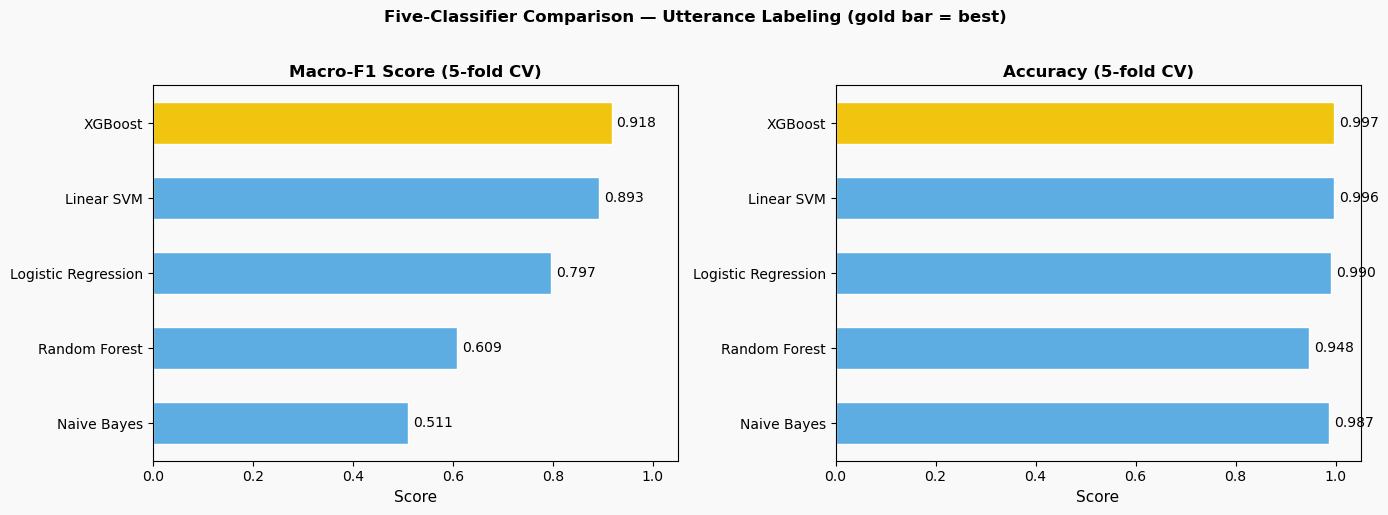

Saved: outputs/model_comparison.png


In [247]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f9f9f9')

# Gold is the winner, blue for the rest
bar_colors = ['#f1c40f' if i == 0 else '#5dade2'
              for i in range(len(summary))]

for ax, metric, title in zip(
    axes,
    ['Macro-F1', 'Accuracy'],
    ['Macro-F1 Score (5-fold CV)', 'Accuracy (5-fold CV)']
):
    ordered_models = summary['Model'][::-1]
    ordered_values = summary[metric][::-1]
    bars = ax.barh(
        ordered_models, ordered_values,
        color=bar_colors[::-1],
        edgecolor='white', height=0.55
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Score', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_facecolor('#f9f9f9')
    for bar, val in zip(bars, ordered_values):
        ax.text(
            val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10
        )

plt.suptitle(
    'Five-Classifier Comparison — Utterance Labeling (gold bar = best)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: outputs/model_comparison.png')

## 6. Per-Class Reports

In [248]:
# Printing the full classification report for every model
# to see where precision or recall drops
for name in summary['Model']:
    divider = '=' * 55
    print(f'\n{divider}')
    print(f'  {name}')
    print(divider)
    print(report_strs[name])


  XGBoost
              precision    recall  f1-score   support

      action      0.957     0.835     0.892      2033
    decision      0.967     0.779     0.863       190
  discussion      0.997     0.999     0.998    132019

    accuracy                          0.997    134242
   macro avg      0.974     0.871     0.918    134242
weighted avg      0.997     0.997     0.996    134242


  Linear SVM
              precision    recall  f1-score   support

      action      0.915     0.868     0.891      2033
    decision      0.917     0.695     0.790       190
  discussion      0.998     0.999     0.998    132019

    accuracy                          0.996    134242
   macro avg      0.943     0.854     0.893    134242
weighted avg      0.996     0.996     0.996    134242


  Logistic Regression
              precision    recall  f1-score   support

      action      0.661     0.950     0.780      2033
    decision      0.482     0.853     0.616       190
  discussion      0.999    

## 7. Normalized Confusion Matrices

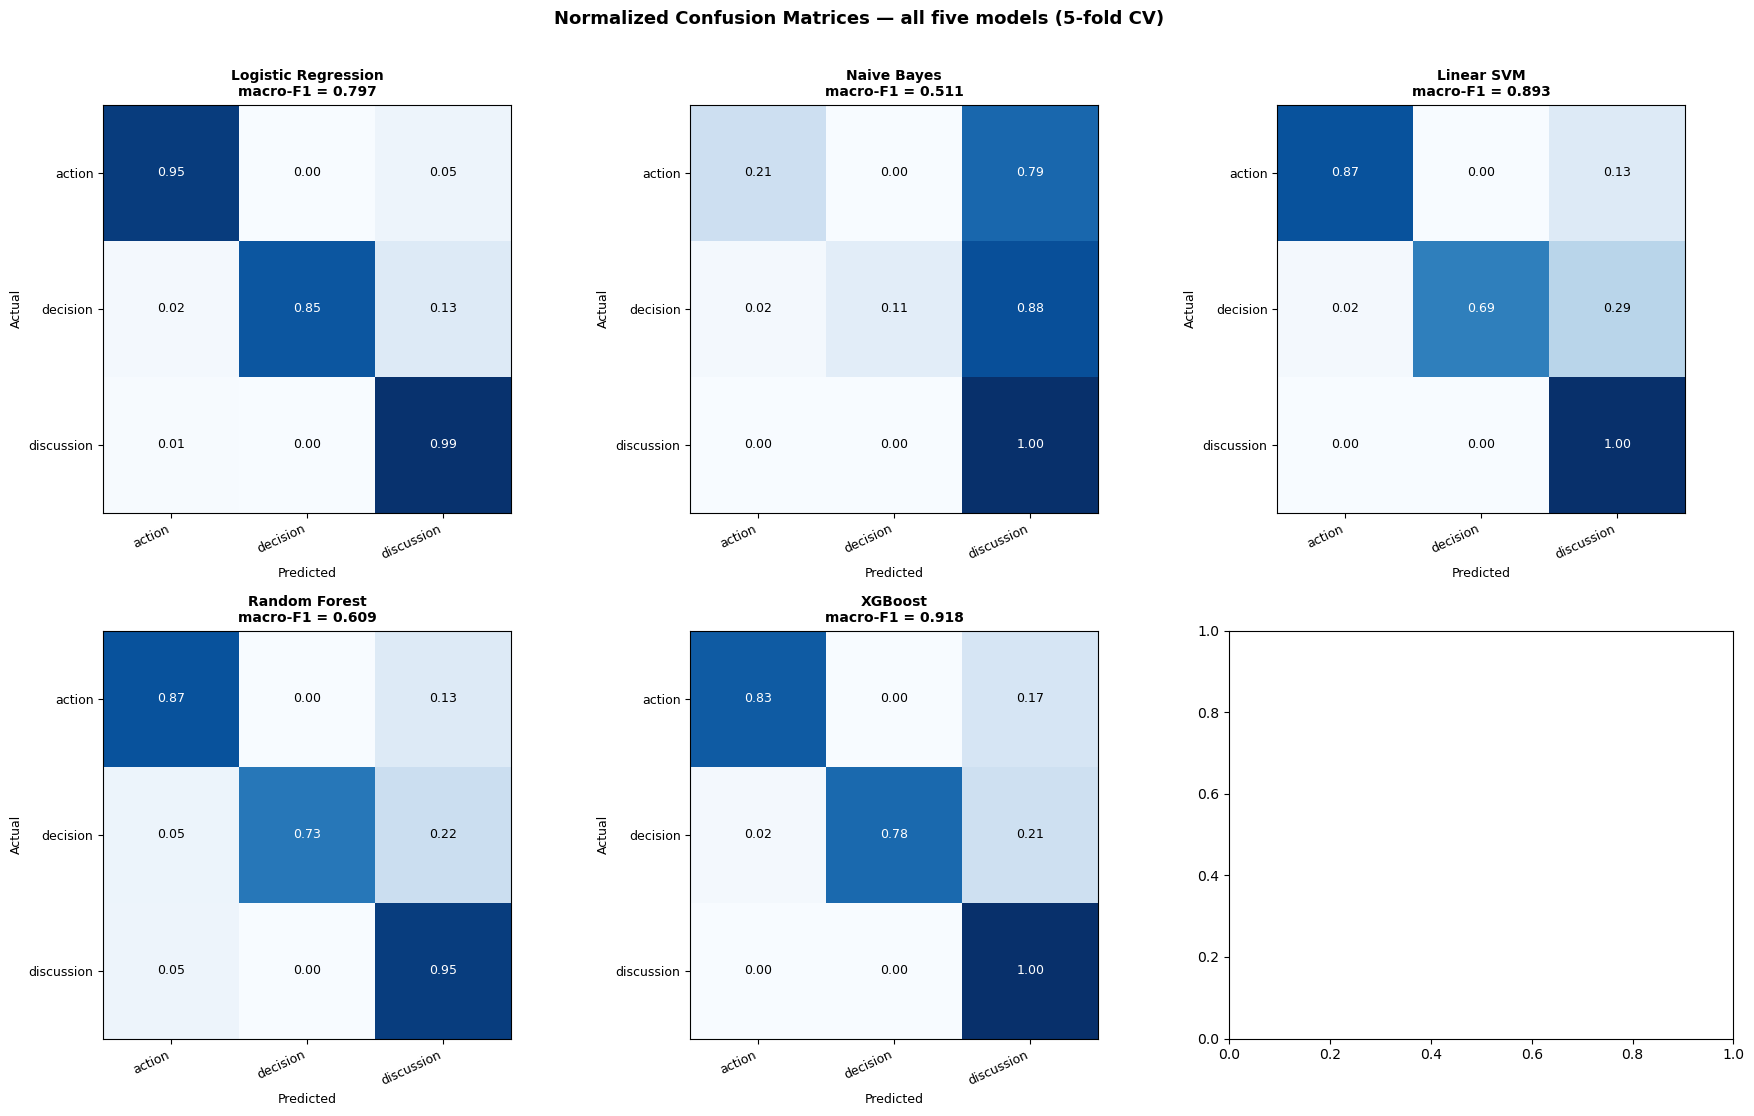

Saved: outputs/confusion_matrices_all.png


In [249]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
flat_axes = axes.flatten()

for ax, (name, vals) in zip(flat_axes, cv_results.items()):
    cm      = confusion_matrix(y, vals['oof'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(
        f'{name}\nmacro-F1 = {vals["macro_f1"]:.3f}',
        fontweight='bold', fontsize=10
    )
    for r in range(len(CLASS_NAMES)):
        for c in range(len(CLASS_NAMES)):
            ax.text(
                c, r, f'{cm_norm[r, c]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if cm_norm[r, c] > 0.55 else 'black'
            )

# flat_axes[-1].set_visible(False)   

plt.suptitle(
    'Normalized Confusion Matrices — all five models (5-fold CV)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: outputs/confusion_matrices_all.png')

## 8. Fit Best Model on Full Data

The model with the highest macro-F1 is retrained on every utterance and serialised for the dashboard and Milestone 3 Streamlit app deployement.

In [250]:
best_name = summary.iloc[0]['Model']
print(f'Best model  : {best_name}')
print(f'Macro-F1    : {summary.iloc[0]["Macro-F1"]:.3f}')
print(f'Accuracy    : {summary.iloc[0]["Accuracy"]:.3f}')

# Wraping TF-IDF + classifier in a single pipeline so inference is one .predict() call
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=15_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ('clf', MODELS[best_name]),
])
best_pipeline.fit(X_raw, y)

os.makedirs('models', exist_ok=True)
joblib.dump(best_pipeline, 'models/best_classifier.pkl')
joblib.dump(le,            'models/label_encoder.pkl')
print('\nSaved: models/best_classifier.pkl')
print('Saved: models/label_encoder.pkl')

Best model  : XGBoost
Macro-F1    : 0.918
Accuracy    : 0.997

Saved: models/best_classifier.pkl
Saved: models/label_encoder.pkl


## 9. Feature Importance

Understanding which words drive each prediction helps validate that the model is learning genuine meeting-language patterns rather than noise.

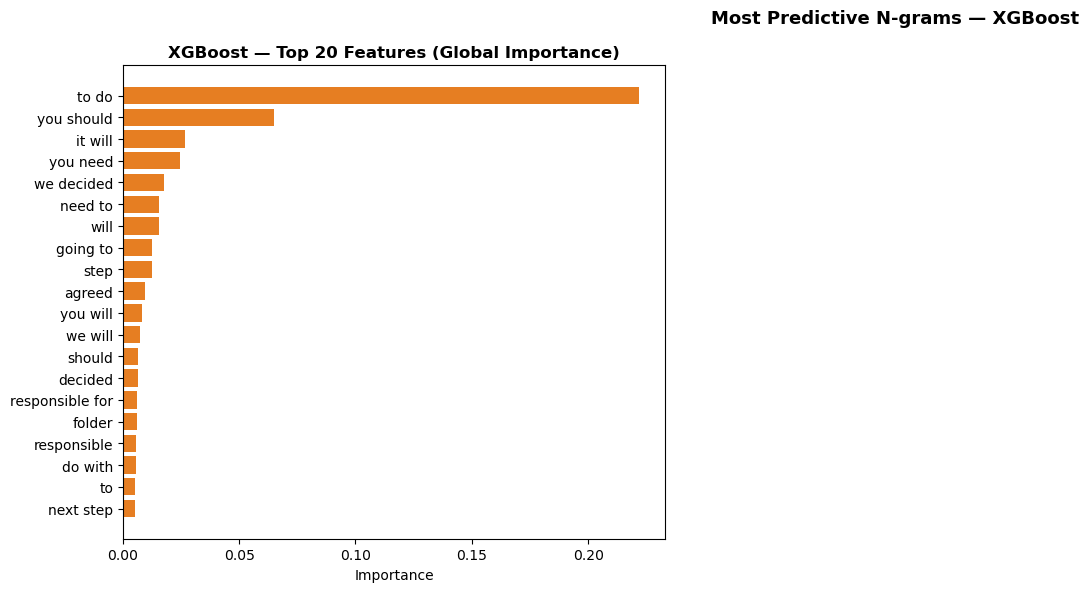

Saved: outputs/feature_importance.png


In [251]:
feature_names = np.array(
    best_pipeline.named_steps['tfidf'].get_feature_names_out()
)
clf_step = best_pipeline.named_steps['clf']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if hasattr(clf_step, 'coef_'):
    # Logistic Regression or Linear SVM: plot per-class coefficients
    coef_matrix = clf_step.coef_
    for ax, cls_name, coef_row in zip(axes, CLASS_NAMES, coef_matrix):
        top_idx = np.argsort(coef_row)[-15:][::-1]
        ax.barh(feature_names[top_idx][::-1], coef_row[top_idx][::-1], color='#3498db')
        ax.set_title(f'Top features for "{cls_name}"', fontweight='bold')
        ax.set_xlabel('Coefficient')

elif hasattr(clf_step, 'feature_importances_'):
    # Random Forest or XGBoost: single global importance ranking
    importances = clf_step.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]
    axes[0].barh(feature_names[top_idx][::-1], importances[top_idx][::-1], color='#e67e22')
    axes[0].set_title(f'{best_name} — Top 20 Features (Global Importance)', fontweight='bold')
    axes[0].set_xlabel('Importance')
    axes[1].set_visible(False)
    axes[2].set_visible(False)

else:
    # Naive Bayes: use log-probabilities
    for ax, cls_name, log_prob in zip(axes, CLASS_NAMES, clf_step.feature_log_prob_):
        top_idx = np.argsort(log_prob)[-15:][::-1]
        ax.barh(feature_names[top_idx][::-1], log_prob[top_idx][::-1], color='#8e44ad')
        ax.set_title(f'Top features for "{cls_name}"', fontweight='bold')
        ax.set_xlabel('Log Probability')

plt.suptitle(f'Most Predictive N-grams — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: outputs/feature_importance.png')

## 10. Error Analysis

Inspecting misclassified utterances tells us where the model struggles and what we might improve next.

In [252]:
best_oof = cv_results[best_name]['oof']

df['pred_label'] = le.inverse_transform(best_oof)
df['correct']    = (df['pred_label'] == df['label']).astype(int)

errors = df[df['correct'] == 0][['meeting_id', 'text_clean', 'label', 'pred_label']]

total_errors = len(errors)
error_rate   = total_errors / len(df)
print(f'Misclassified : {total_errors:,} / {len(df):,}  ({error_rate:.2%})')
print(f'\nErrors by true label:')
print(errors['label'].value_counts())

print(f'\nMost common confusion pairs (true -> predicted):')
pair_counts = (
    errors.groupby(['label', 'pred_label'])
          .size()
          .reset_index(name='count')
          .sort_values('count', ascending=False)
)
print(pair_counts.head(10).to_string(index=False))

# Saving a random sample for manual review
errors.sample(min(300, len(errors)), random_state=42)\
      .to_csv('outputs/error_analysis.csv', index=False)
print('\nSample saved: outputs/error_analysis.csv')

Misclassified : 456 / 134,242  (0.34%)

Errors by true label:
label
action        336
discussion     78
decision       42
Name: count, dtype: int64

Most common confusion pairs (true -> predicted):
     label pred_label  count
    action discussion    336
discussion     action     73
  decision discussion     39
discussion   decision      5
  decision     action      3

Sample saved: outputs/error_analysis.csv


## 11. Meeting-Level Clustering

Beyond classifying utterances, we want to group meetings by their overall efficiency profile.  
K-Means on four meeting-level features: decision density, action density, redundancy, action clarity.

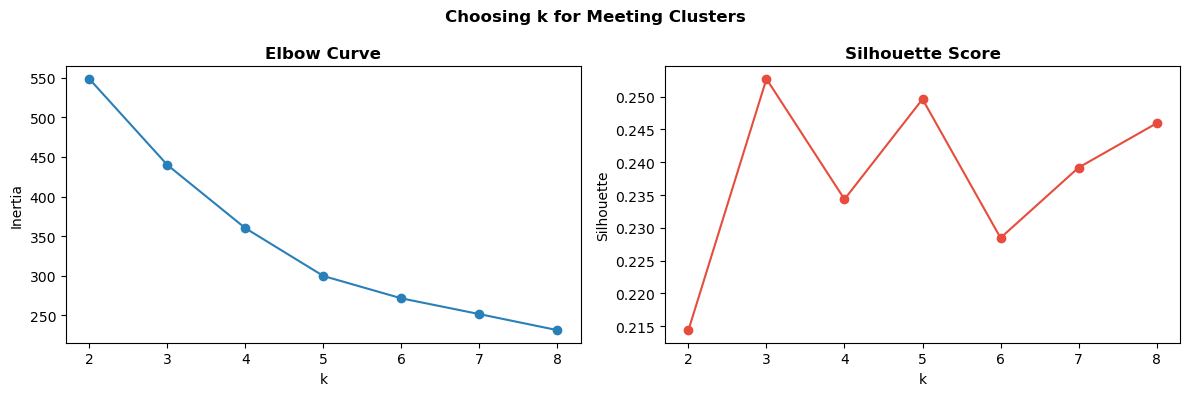

Best k: 3  (silhouette = 0.253)


In [253]:
CLUSTER_FEATS = [
    'decision_density', 'action_density',
    'redundancy_score', 'action_clarity'
]

X_meet        = df_meets[CLUSTER_FEATS].fillna(0).values
scaler        = StandardScaler()
X_meet_scaled = scaler.fit_transform(X_meet)

inertias, silhouettes = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km      = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_ = km.fit_predict(X_meet_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_meet_scaled, labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, marker='o', color='#2980b9')
ax1.set_title('Elbow Curve', fontweight='bold')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(list(K_RANGE), silhouettes, marker='o', color='#e74c3c')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')

plt.suptitle('Choosing k for Meeting Clusters', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/kmeans_selection.png', dpi=130, bbox_inches='tight')
plt.show()

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f'Best k: {best_k}  (silhouette = {max(silhouettes):.3f})')

In [254]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_meets['cluster'] = km_final.fit_predict(X_meet_scaled)

# Ranking clusters by average efficiency
rank_order = (
    df_meets.groupby('cluster')['efficiency_score']
            .mean()
            .sort_values(ascending=False)
            .index
)
possible_labels = [
    'Highly Efficient', 'Moderately Efficient',
    'Low Efficiency', 'Very Low Efficiency'
]
label_map = {cid: possible_labels[i] for i, cid in enumerate(rank_order)}
df_meets['cluster_label'] = df_meets['cluster'].map(label_map)

print('Meetings per cluster:')
print(df_meets['cluster_label'].value_counts())
print('\nCluster means:')
print(
    df_meets.groupby('cluster_label')[CLUSTER_FEATS + ['efficiency_score']]
            .mean()
            .round(3)
            .to_string()
)

Meetings per cluster:
cluster_label
Low Efficiency          97
Highly Efficient        42
Moderately Efficient    32
Name: count, dtype: int64

Cluster means:
                      decision_density  action_density  redundancy_score  action_clarity  efficiency_score
cluster_label                                                                                             
Highly Efficient                 0.000           0.026             0.143           0.410             0.265
Low Efficiency                   0.001           0.013             0.215           0.178             0.240
Moderately Efficient             0.005           0.015             0.145           0.208             0.263


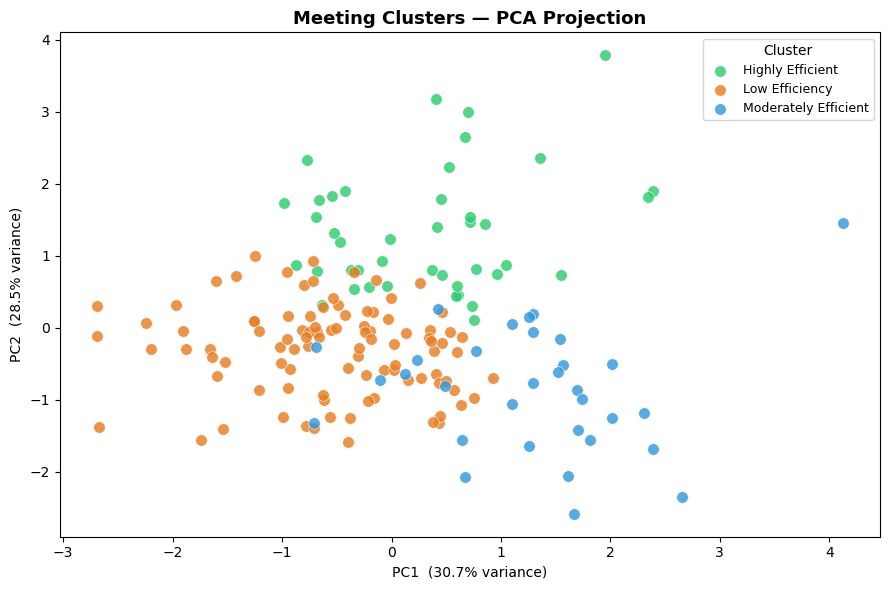

Saved: outputs/meeting_clusters.png


In [255]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_meet_scaled)
df_meets['pca_x'] = coords[:, 0]
df_meets['pca_y'] = coords[:, 1]

CLUSTER_COLORS = {
    'Highly Efficient'     : '#2ecc71',
    'Moderately Efficient' : '#3498db',
    'Low Efficiency'       : '#e67e22',
    'Very Low Efficiency'  : '#e74c3c',
}

fig, ax = plt.subplots(figsize=(9, 6))
for lbl, grp in df_meets.groupby('cluster_label'):
    ax.scatter(
        grp['pca_x'], grp['pca_y'],
        label=lbl,
        color=CLUSTER_COLORS.get(lbl, '#95a5a6'),
        s=70, alpha=0.82, edgecolors='white', linewidths=0.5
    )
ax.set_title('Meeting Clusters — PCA Projection', fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/meeting_clusters.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: outputs/meeting_clusters.png')

## 12. Save All Outputs

In [256]:
# Utterances with CV predictions for data_visualisation
df.to_csv('data/processed/analysis_ready_with_preds.csv', index=False)

# Meetings with cluster assignments
df_meets.to_csv('data/processed/meeting_metrics_clustered.csv', index=False)

# Model comparison table for the dashboard
summary.to_csv('outputs/model_comparison_summary.csv', index=False)

# Serialised cluster model
joblib.dump(km_final, 'models/kmeans_clusters.pkl')
joblib.dump(scaler,   'models/cluster_scaler.pkl')

print('All outputs saved:')
for path in [
    'data/processed/analysis_ready_with_preds.csv',
    'data/processed/meeting_metrics_clustered.csv',
    'outputs/model_comparison_summary.csv',
    'models/best_classifier.pkl',
    'models/label_encoder.pkl',
    'models/kmeans_clusters.pkl',
    'models/cluster_scaler.pkl',
]:
    print(f'  {path}')

All outputs saved:
  data/processed/analysis_ready_with_preds.csv
  data/processed/meeting_metrics_clustered.csv
  outputs/model_comparison_summary.csv
  models/best_classifier.pkl
  models/label_encoder.pkl
  models/kmeans_clusters.pkl
  models/cluster_scaler.pkl


## Summary

**What we built here:**
- Five classifiers trained and evaluated on the same TF-IDF features with 5-fold stratified CV.
- Class imbalance addressed for every model so minority labels (decision, action) aren't drowned out.
- Best model retrained on all data and saved for downstream use.
- K-Means clustering grouped meetings into efficiency tiers with interpretable labels.

**What the error patterns typically show:**
- The main confusion is between *action* and *discussion* — action utterances are often phrased informally and lack strong cue words.
- *Decision* utterances are short in the AMI corpus, which makes them easier to miss.

**Next step:**  
Run `data_visualization_static.ipynb` to explore all of these findings through the interactive dashboard.